# 05c2 — Compare Scenario A Robustness Sweeps: Greedy (05a) vs QAOA (05b) vs QAOA+Aer (05b2)

This notebook compares the **Scenario A** robustness sweep outputs across three methods:

- **05a (Greedy)**
- **05b (QAOA, Aer-free mode from earlier workflow)**
- **05b2 (QAOA with Aer, standalone optimized run)**

## Goals
1) Compare the **best-performing configurations** per method (objective + stability).
2) Compare method performance on **overlapping config grids** where possible.
3) Compare **selection overlap (Jaccard)** between methods for shared configurations.

## Inputs (expected artifacts)
From `data/results/`:
- `05a_greedy_top_config_table.csv`
- `05a_greedy_top_configs_selected_trials.csv`
- `05b_qaoa_top_config_table.csv`
- `05b_qaoa_top_configs_selected_trials.csv`
- `05b2_qaoa_aer_top_config_table.csv`
- `05b2_qaoa_aer_top_configs_selected_trials.csv`

Optional (if present) robustness summaries:
- `*_robustness_sweep_summary.csv`

## Outputs
To `data/results/`:
- `05c2_compare_config_join_table.csv`
- `05c2_compare_best_by_method.csv`
- `05c2_compare_selection_overlap_jaccard.csv`

To `outputs/figures/`:
- `05c2_best_objective_by_method.png`
- `05c2_objective_vs_stability_scatter.png`
- `05c2_jaccard_overlap_heatmap.png`


In [2]:
# ============================================================
# Cell 1 — Setup: imports, paths, and artifact checks
# ============================================================

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

RESULTS_DIR = Path("data/results")
FIG_DIR = Path("outputs/figures")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- Expected artifacts ---
PATHS = {
    "05a_top": RESULTS_DIR / "05a_greedy_top_config_table.csv",
    "05a_sel": RESULTS_DIR / "05a_greedy_top_configs_selected_trials.csv",
    "05b_top": RESULTS_DIR / "05b_qaoa_top_config_table.csv",
    "05b_sel": RESULTS_DIR / "05b_qaoa_top_configs_selected_trials.csv",
    "05b2_top": RESULTS_DIR / "05b2_qaoa_aer_top_config_table.csv",
    "05b2_sel": RESULTS_DIR / "05b2_qaoa_aer_top_configs_selected_trials.csv",
    # Optional summaries (nice-to-have for deeper analysis)
    "05a_sum": RESULTS_DIR / "05a_greedy_robustness_sweep_summary.csv",
    "05b_sum": RESULTS_DIR / "05b_qaoa_robustness_sweep_summary.csv",
    "05b2_sum": RESULTS_DIR / "05b2_qaoa_aer_robustness_sweep_summary.csv",
}

required = ["05a_top", "05a_sel", "05b_top", "05b_sel", "05b2_top", "05b2_sel"]
missing = [k for k in required if not PATHS[k].exists()]
if missing:
    raise FileNotFoundError(
        "Missing required comparison artifacts:\n  - "
        + "\n  - ".join([f"{k}: {PATHS[k]}" for k in missing])
        + "\n\nFix: make sure you ran/pushed 05a, 05b, and 05b2 and that these files exist in data/results/."
    )

print("OK: Found required artifacts.")
print("Results dir:", RESULTS_DIR.resolve())
print("Figures dir:", FIG_DIR.resolve())

print("\nOptional summaries present:")
for k in ["05a_sum", "05b_sum", "05b2_sum"]:
    print(f"  - {k}: {PATHS[k].exists()} ({PATHS[k]})")


OK: Found required artifacts.
Results dir: /home/parallels/projects/quantum-clinical-trial-optimization/data/results
Figures dir: /home/parallels/projects/quantum-clinical-trial-optimization/outputs/figures

Optional summaries present:
  - 05a_sum: True (data/results/05a_greedy_robustness_sweep_summary.csv)
  - 05b_sum: True (data/results/05b_qaoa_robustness_sweep_summary.csv)
  - 05b2_sum: True (data/results/05b2_qaoa_aer_robustness_sweep_summary.csv)


### What Cell 1 Just Did

- Defined the project output directories and standard artifact paths.
- Verified all required comparison artifacts exist for 05a, 05b, and 05b2.
- Reported whether optional sweep summaries are available for deeper follow-on analysis.


In [3]:
# ============================================================
# Cell 2 — Load artifacts (top tables + selected trials)
# ============================================================

def read_csv(path: Path, label: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    if df.empty:
        raise ValueError(f"{label} loaded empty: {path}")
    return df

# Top config tables (already aggregated per-config in your sweeps)
top_05a = read_csv(PATHS["05a_top"], "05a_top")
top_05b = read_csv(PATHS["05b_top"], "05b_top")
top_05b2 = read_csv(PATHS["05b2_top"], "05b2_top")

# Selected trials for top configs
sel_05a = read_csv(PATHS["05a_sel"], "05a_sel")
sel_05b = read_csv(PATHS["05b_sel"], "05b_sel")
sel_05b2 = read_csv(PATHS["05b2_sel"], "05b2_sel")

print("Loaded shapes:")
print("  top_05a :", top_05a.shape, "| sel_05a :", sel_05a.shape)
print("  top_05b :", top_05b.shape, "| sel_05b :", sel_05b.shape)
print("  top_05b2:", top_05b2.shape, "| sel_05b2:", sel_05b2.shape)

print("\nTop table columns (first 20):")
print("  05a :", list(top_05a.columns)[:20])
print("  05b :", list(top_05b.columns)[:20])
print("  05b2:", list(top_05b2.columns)[:20])


Loaded shapes:
  top_05a : (10, 10) | sel_05a : (375, 24)
  top_05b : (10, 14) | sel_05b : (63, 27)
  top_05b2: (10, 13) | sel_05b2: (54, 31)

Top table columns (first 20):
  05a : ['K', 'lambda_cost', 'lambda_safety', 'noise_sigma', 'objective_mean', 'objective_std', 'objective_norm_mean', 'jaccard_mean', 'jaccard_std', 'n_runs']
  05b : ['K', 'lambda_cost', 'lambda_safety', 'noise_sigma', 'pool_size', 'p', 'penalty_A', 'shots', 'objective_mean', 'objective_std', 'objective_norm_mean', 'jaccard_mean', 'jaccard_std', 'n_runs']
  05b2: ['K', 'lambda_cost', 'lambda_safety', 'noise_sigma', 'pool_size', 'penalty_A', 'shots', 'objective_mean', 'objective_std', 'objective_norm_mean', 'jaccard_mean', 'jaccard_std', 'n_runs']


### What Cell 2 Just Did

- Loaded the aggregated “top config” tables for 05a, 05b, and 05b2 from disk.
- Loaded the “selected trials per top config” tables for overlap analysis.
- Printed shapes and a quick column preview so schema differences are visible early.

In [4]:
# ============================================================
# Cell 3 — Standardize schemas + build stable join keys
# ============================================================

CORE_KEYS = ["K", "lambda_cost", "lambda_safety", "noise_sigma"]

def ensure_columns(df: pd.DataFrame, cols: list, fill=np.nan) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        if c not in out.columns:
            out[c] = fill
    return out

def coerce_numeric(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

def add_method(df: pd.DataFrame, method: str) -> pd.DataFrame:
    out = df.copy()
    out["method"] = method
    return out

def add_join_key(df: pd.DataFrame, decimals: int = 3) -> pd.DataFrame:
    """
    Adds a robust string join key over (K, lambda_cost, lambda_safety, noise_sigma),
    rounding float components to avoid float-join surprises.
    """
    out = df.copy()

    out = ensure_columns(out, CORE_KEYS)
    out = coerce_numeric(out, CORE_KEYS)

    # rounding for join stability
    out["_K_int"] = out["K"].astype("Int64")
    out["_lc_r"] = out["lambda_cost"].round(decimals)
    out["_ls_r"] = out["lambda_safety"].round(decimals)
    out["_sig_r"] = out["noise_sigma"].round(decimals)

    out["_config_key"] = (
        "K=" + out["_K_int"].astype(str) +
        "|lc=" + out["_lc_r"].astype(str) +
        "|ls=" + out["_ls_r"].astype(str) +
        "|sig=" + out["_sig_r"].astype(str)
    )
    return out

# Expected “score columns” used in top tables (if present)
TOP_METRIC_COLS = [
    "objective_mean", "objective_std", "objective_norm_mean",
    "jaccard_mean", "jaccard_std", "n_runs"
]

def standardize_top_table(df: pd.DataFrame, method: str) -> pd.DataFrame:
    out = df.copy()

    # make sure the core key columns exist (some earlier tables had odd schema)
    out = ensure_columns(out, CORE_KEYS)

    # make sure metric columns exist (fill NaN if absent)
    out = ensure_columns(out, TOP_METRIC_COLS)

    # coerce types
    out = coerce_numeric(out, CORE_KEYS + TOP_METRIC_COLS)

    # attach method + join key
    out = add_method(out, method)
    out = add_join_key(out, decimals=3)

    # keep a clean view
    keep = ["method", "_config_key"] + CORE_KEYS + TOP_METRIC_COLS
    extra = [c for c in out.columns if c not in keep]
    # include a few extras if present and useful
    for c in ["pool_size", "p", "penalty_A", "shots"]:
        if c in out.columns and c not in keep:
            keep.append(c)
    return out[keep + [c for c in extra if c in ["pool_size", "p", "penalty_A", "shots"]]]

top_05a_s = standardize_top_table(top_05a, "05a_greedy")
top_05b_s = standardize_top_table(top_05b, "05b_qaoa")
top_05b2_s = standardize_top_table(top_05b2, "05b2_qaoa_aer")

print("Standardized top tables (columns):")
print("  05a :", list(top_05a_s.columns))
print("  05b :", list(top_05b_s.columns))
print("  05b2:", list(top_05b2_s.columns))

display(top_05a_s.head(5))
display(top_05b_s.head(5))
display(top_05b2_s.head(5))


Standardized top tables (columns):
  05a : ['method', '_config_key', 'K', 'lambda_cost', 'lambda_safety', 'noise_sigma', 'objective_mean', 'objective_std', 'objective_norm_mean', 'jaccard_mean', 'jaccard_std', 'n_runs']
  05b : ['method', '_config_key', 'K', 'lambda_cost', 'lambda_safety', 'noise_sigma', 'objective_mean', 'objective_std', 'objective_norm_mean', 'jaccard_mean', 'jaccard_std', 'n_runs', 'pool_size', 'p', 'penalty_A', 'shots', 'pool_size', 'p', 'penalty_A', 'shots']
  05b2: ['method', '_config_key', 'K', 'lambda_cost', 'lambda_safety', 'noise_sigma', 'objective_mean', 'objective_std', 'objective_norm_mean', 'jaccard_mean', 'jaccard_std', 'n_runs', 'pool_size', 'penalty_A', 'shots', 'pool_size', 'penalty_A', 'shots']


,method,_config_key,K,lambda_cost,lambda_safety,noise_sigma,objective_mean,objective_std,objective_norm_mean,jaccard_mean,jaccard_std,n_runs
0,05a_greedy,K=25|lc=0.5|ls=0.5|sig=0.1,25,0.5,0.5,0.1,-1.441677,0.118359,0.999457,0.002703,0.006043,5
1,05a_greedy,K=25|lc=0.5|ls=1.0|sig=0.1,25,0.5,1.0,0.1,-1.441677,0.118359,0.999457,0.002703,0.006043,5
2,05a_greedy,K=25|lc=0.5|ls=2.0|sig=0.1,25,0.5,2.0,0.1,-1.441677,0.118359,0.999457,0.002703,0.006043,5
3,05a_greedy,K=50|lc=0.5|ls=0.5|sig=0.1,50,0.5,0.5,0.1,-4.018448,0.166197,0.989300,0.002020,0.004517,5
4,05a_greedy,K=50|lc=0.5|ls=1.0|sig=0.1,50,0.5,1.0,0.1,-4.018448,0.166197,0.989300,0.002020,0.004517,5


,method,_config_key,K,lambda_cost,lambda_safety,noise_sigma,objective_mean,objective_std,objective_norm_mean,jaccard_mean,jaccard_std,n_runs,pool_size,p,penalty_A,shots,pool_size,p,penalty_A,shots
0,05b_qaoa,K=6|lc=0.5|ls=0.5|sig=0.1,6,0.5,0.5,0.10,-1.951298,0.106528,0.996850,0.363636,0.00000,3,12,1,10.0,128,12,1,10.0,128
1,05b_qaoa,K=6|lc=0.5|ls=1.0|sig=0.1,6,0.5,1.0,0.10,-1.951298,0.106528,0.996850,0.363636,0.00000,3,12,1,10.0,128,12,1,10.0,128
2,05b_qaoa,K=6|lc=0.5|ls=2.0|sig=0.1,6,0.5,2.0,0.10,-1.951298,0.106528,0.996850,0.363636,0.00000,3,12,1,10.0,128,12,1,10.0,128
3,05b_qaoa,K=6|lc=0.5|ls=0.5|sig=0.05,6,0.5,0.5,0.05,-2.181031,0.062375,0.990965,0.409091,0.07873,3,12,1,10.0,128,12,1,10.0,128
4,05b_qaoa,K=6|lc=0.5|ls=1.0|sig=0.05,6,0.5,1.0,0.05,-2.181031,0.062375,0.990965,0.409091,0.07873,3,12,1,10.0,128,12,1,10.0,128


,method,_config_key,K,lambda_cost,lambda_safety,noise_sigma,objective_mean,objective_std,objective_norm_mean,jaccard_mean,jaccard_std,n_runs,pool_size,penalty_A,shots,pool_size,penalty_A,shots
0,05b2_qaoa_aer,K=6|lc=0.5|ls=2.0|sig=0.0,6,0.5,2.0,0.00,12.000000,0.000000,1.000000,1.0,0.0,3,6,10.0,1024,6,10.0,1024
1,05b2_qaoa_aer,K=6|lc=1.0|ls=2.0|sig=0.0,6,1.0,2.0,0.00,12.000000,0.000000,1.000000,1.0,0.0,3,6,10.0,1024,6,10.0,1024
2,05b2_qaoa_aer,K=6|lc=2.0|ls=2.0|sig=0.0,6,2.0,2.0,0.00,12.000000,0.000000,1.000000,1.0,0.0,3,6,10.0,1024,6,10.0,1024
3,05b2_qaoa_aer,K=6|lc=2.0|ls=2.0|sig=0.1,6,2.0,2.0,0.10,8.453292,2.197482,0.738262,1.0,0.0,3,6,10.0,1024,6,10.0,1024
4,05b2_qaoa_aer,K=6|lc=2.0|ls=2.0|sig=0.05,6,2.0,2.0,0.05,8.433709,2.206996,0.736817,1.0,0.0,3,6,10.0,1024,6,10.0,1024


### What Cell 3 Just Did

- Standardized the three top-config tables so they share a consistent set of key and metric columns.
- Built a stable string join key (`_config_key`) over (K, λ_cost, λ_safety, noise_sigma) with rounding to avoid float-merge issues.
- Ensured missing columns do not crash the notebook (they become NaN), allowing comparisons even when schemas differ.


In [6]:
# ============================================================
# Cell 4 — Cross-method config comparison (best-by-method + join table) [FIXED]
# ============================================================

def _dedupe_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Ensure columns are uniquely named (guards against accidental duplicates that break concat).
    If duplicates exist, suffix them deterministically: col, col__dup1, col__dup2, ...
    """
    cols = list(df.columns)
    seen = {}
    new_cols = []
    for c in cols:
        if c not in seen:
            seen[c] = 0
            new_cols.append(c)
        else:
            seen[c] += 1
            new_cols.append(f"{c}__dup{seen[c]}")
    out = df.copy()
    out.columns = new_cols
    return out

def best_by_method(top_df: pd.DataFrame) -> pd.DataFrame:
    """
    Choose the single best config by objective_norm_mean, tie-break by jaccard_mean.
    If objective_norm_mean is all-NaN, create a fallback normalization from objective_mean.
    Always returns a 1-row DataFrame with unique columns.
    """
    df = _dedupe_columns(top_df.copy())

    # If objective_norm_mean is entirely NaN, create fallback normalized score from objective_mean
    if "objective_norm_mean" not in df.columns or df["objective_norm_mean"].isna().all():
        if "objective_mean" not in df.columns:
            raise ValueError("Cannot rank configs: missing both objective_norm_mean and objective_mean.")
        x = pd.to_numeric(df["objective_mean"], errors="coerce").astype(float)
        xmin = float(np.nanmin(x))
        xmax = float(np.nanmax(x))
        den = (xmax - xmin) if xmax > xmin else 1.0
        df["objective_norm_mean"] = (x - xmin) / den

    if "jaccard_mean" not in df.columns:
        df["jaccard_mean"] = np.nan

    df["objective_norm_mean"] = pd.to_numeric(df["objective_norm_mean"], errors="coerce")
    df["jaccard_mean"] = pd.to_numeric(df["jaccard_mean"], errors="coerce")

    df_sorted = df.sort_values(["objective_norm_mean", "jaccard_mean"], ascending=[False, False])
    best = df_sorted.head(1).reset_index(drop=True)
    return _dedupe_columns(best)

best_05a = best_by_method(top_05a_s)
best_05b = best_by_method(top_05b_s)
best_05b2 = best_by_method(top_05b2_s)

# Align columns before concat (prevents pandas trying to reindex against duplicate labels)
all_cols = sorted(set(best_05a.columns) | set(best_05b.columns) | set(best_05b2.columns))
best_05a = best_05a.reindex(columns=all_cols)
best_05b = best_05b.reindex(columns=all_cols)
best_05b2 = best_05b2.reindex(columns=all_cols)

best_all = pd.concat([best_05a, best_05b, best_05b2], ignore_index=True)
best_out = RESULTS_DIR / "05c2_compare_best_by_method.csv"
best_all.to_csv(best_out, index=False)
print("Wrote:", best_out)
display(best_all)

# ------------------------------------------------------------
# Join tables across methods on the config key to show overlap
# ------------------------------------------------------------
a = _dedupe_columns(top_05a_s.copy()).add_prefix("a__")
b = _dedupe_columns(top_05b_s.copy()).add_prefix("b__")
c = _dedupe_columns(top_05b2_s.copy()).add_prefix("c__")

join = a.merge(b, left_on="a___config_key", right_on="b___config_key", how="outer")
join = join.merge(c, left_on="a___config_key", right_on="c___config_key", how="outer")

join["config_key"] = join["a___config_key"].fillna(join["b___config_key"]).fillna(join["c___config_key"])
join = join.drop(columns=[col for col in ["a___config_key", "b___config_key", "c___config_key"] if col in join.columns])

def pick_cols(prefix):
    cols = [
        f"{prefix}__K", f"{prefix}__lambda_cost", f"{prefix}__lambda_safety", f"{prefix}__noise_sigma",
        f"{prefix}__objective_norm_mean", f"{prefix}__objective_mean", f"{prefix}__jaccard_mean", f"{prefix}__n_runs"
    ]
    return [c for c in cols if c in join.columns]

cols_show = ["config_key"] + pick_cols("a") + pick_cols("b") + pick_cols("c")

join_out = RESULTS_DIR / "05c2_compare_config_join_table.csv"
join[cols_show].to_csv(join_out, index=False)
print("Wrote:", join_out)

print("\nOverlap diagnostics:")
common_ab = set(top_05a_s["_config_key"]) & set(top_05b_s["_config_key"])
common_ac = set(top_05a_s["_config_key"]) & set(top_05b2_s["_config_key"])
common_bc = set(top_05b_s["_config_key"]) & set(top_05b2_s["_config_key"])
common_abc = set(top_05a_s["_config_key"]) & set(top_05b_s["_config_key"]) & set(top_05b2_s["_config_key"])

print("  Overlap 05a∩05b :", len(common_ab))
print("  Overlap 05a∩05b2:", len(common_ac))
print("  Overlap 05b∩05b2:", len(common_bc))
print("  Overlap all three:", len(common_abc))

display(join[cols_show].head(15))

Wrote: data/results/05c2_compare_best_by_method.csv


,K,_config_key,jaccard_mean,jaccard_std,lambda_cost,lambda_safety,method,n_runs,noise_sigma,objective_mean,objective_norm_mean,objective_std,p,p__dup1,penalty_A,penalty_A__dup1,pool_size,pool_size__dup1,shots,shots__dup1
0,25,K=25|lc=0.5|ls=0.5|sig=0.1,0.002703,0.006043,0.5,0.5,05a_greedy,5,0.1,-1.441677,0.999457,0.118359,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6,K=6|lc=0.5|ls=0.5|sig=0.1,0.363636,0.000000,0.5,0.5,05b_qaoa,3,0.1,-1.951298,0.996850,0.106528,1.0,1.0,10.0,10.0,12.0,12.0,128.0,128.0
2,6,K=6|lc=0.5|ls=2.0|sig=0.0,1.000000,0.000000,0.5,2.0,05b2_qaoa_aer,3,0.0,12.000000,1.000000,0.000000,NaN,NaN,10.0,10.0,6.0,6.0,1024.0,1024.0


Wrote: data/results/05c2_compare_config_join_table.csv

Overlap diagnostics:
  Overlap 05a∩05b : 0
  Overlap 05a∩05b2: 0
  Overlap 05b∩05b2: 2
  Overlap all three: 0


,config_key,a__K,a__lambda_cost,a__lambda_safety,a__noise_sigma,a__objective_norm_mean,a__objective_mean,a__jaccard_mean,a__n_runs,b__K,...,b__jaccard_mean,b__n_runs,c__K,c__lambda_cost,c__lambda_safety,c__noise_sigma,c__objective_norm_mean,c__objective_mean,c__jaccard_mean,c__n_runs
0,K=25|lc=0.5|ls=0.5|sig=0.05,25.0,0.5,0.5,0.05,0.982861,-5.652055,0.002703,5.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,K=25|lc=0.5|ls=0.5|sig=0.1,25.0,0.5,0.5,0.10,0.999457,-1.441677,0.002703,5.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,K=25|lc=0.5|ls=1.0|sig=0.05,25.0,0.5,1.0,0.05,0.982861,-5.652055,0.002703,5.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,K=25|lc=0.5|ls=1.0|sig=0.1,25.0,0.5,1.0,0.10,0.999457,-1.441677,0.002703,5.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,K=25|lc=0.5|ls=2.0|sig=0.05,25.0,0.5,2.0,0.05,0.982861,-5.652055,0.002703,5.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,K=25|lc=0.5|ls=2.0|sig=0.1,25.0,0.5,2.0,0.10,0.999457,-1.441677,0.002703,5.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,K=3|lc=0.5|ls=2.0|sig=0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,3.0,0.5,2.0,0.0,0.557215,6.0,0.5,3.0
7,K=3|lc=1.0|ls=2.0|sig=0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,3.0,1.0,2.0,0.0,0.557215,6.0,0.5,3.0
8,K=50|lc=0.5|ls=0.5|sig=0.1,50.0,0.5,0.5,0.10,0.989300,-4.018448,0.002020,5.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,K=50|lc=0.5|ls=1.0|sig=0.1,50.0,0.5,1.0,0.10,0.989300,-4.018448,0.002020,5.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### What Cell 4 Just Did (Fixed)

- Fixed a Pandas `InvalidIndexError` by enforcing **unique column names** and aligning columns prior to concatenation.
- Selected the single “best” configuration per method (ranked by `objective_norm_mean`, then `jaccard_mean`).
- Built a cross-method join table keyed by the standardized configuration key to show which configurations overlap across 05a/05b/05b2.
- Exported:
  - `data/results/05c2_compare_best_by_method.csv`
  - `data/results/05c2_compare_config_join_table.csv`


In [7]:
# ============================================================
# Cell 5 — Selection overlap (Jaccard) across methods for shared configs
# ============================================================

def parse_config_id(config_id: str) -> dict:
    """
    Tries to extract K, lc, ls, sig, seed from a config_id like:
      K12_lc1.0_ls1.0_sig0.05_seed0_pool18_shots1024_A10.0
    Returns dict with any found values.
    """
    s = str(config_id)

    def grab(pattern):
        m = re.search(pattern, s)
        return m.group(1) if m else None

    out = {}
    out["K"] = grab(r"K(\d+)")
    out["lambda_cost"] = grab(r"lc([0-9]*\.?[0-9]+)")
    out["lambda_safety"] = grab(r"ls([0-9]*\.?[0-9]+)")
    out["noise_sigma"] = grab(r"sig([0-9]*\.?[0-9]+)")
    out["seed"] = grab(r"seed(\d+)")
    return out

def standardize_selected_trials(df: pd.DataFrame, method: str) -> pd.DataFrame:
    out = df.copy()
    out["method"] = method

    # Ensure nct_id is present
    if "nct_id" not in out.columns:
        raise ValueError(f"{method}: selected trials file missing nct_id. Columns: {list(out.columns)}")

    # Prefer explicit columns if present; otherwise parse config_id
    out = ensure_columns(out, CORE_KEYS + ["seed", "config_id"])

    # If K etc are missing or all-NaN, attempt parse from config_id
    need_parse = (
        out["K"].isna().all() and
        out["lambda_cost"].isna().all() and
        out["lambda_safety"].isna().all() and
        out["noise_sigma"].isna().all()
    )
    if need_parse and out["config_id"].notna().any():
        parsed = out["config_id"].apply(parse_config_id).apply(pd.Series)
        for c in ["K", "lambda_cost", "lambda_safety", "noise_sigma", "seed"]:
            if c in parsed.columns:
                out[c] = out[c].fillna(parsed[c])

    out = coerce_numeric(out, CORE_KEYS + ["seed"])

    # Add join key (same rounding strategy)
    out = add_join_key(out, decimals=3)

    # Normalize IDs
    out["nct_id"] = out["nct_id"].astype(str)

    return out

sel_05a_s = standardize_selected_trials(sel_05a, "05a_greedy")
sel_05b_s = standardize_selected_trials(sel_05b, "05b_qaoa")
sel_05b2_s = standardize_selected_trials(sel_05b2, "05b2_qaoa_aer")

def selections_by_config(sel_df: pd.DataFrame) -> dict:
    """
    Map: config_key -> set(nct_id)
    """
    m = {}
    for k, g in sel_df.groupby("_config_key"):
        m[str(k)] = set(g["nct_id"].tolist())
    return m

m_a = selections_by_config(sel_05a_s)
m_b = selections_by_config(sel_05b_s)
m_c = selections_by_config(sel_05b2_s)

shared_keys = sorted(set(m_a.keys()) & set(m_b.keys()) & set(m_c.keys()))
if not shared_keys:
    # fall back to pairwise comparison list
    shared_keys = sorted(set(m_a.keys()) & set(m_b.keys()))
    if not shared_keys:
        shared_keys = sorted(set(m_a.keys()) & set(m_c.keys()))
    if not shared_keys:
        shared_keys = sorted(set(m_b.keys()) & set(m_c.keys()))

if not shared_keys:
    raise ValueError(
        "No overlapping config keys across selected-trials exports.\n"
        "This usually means the top-config exports use different config grids.\n"
        "Fix: ensure 05a/05b/05b2 use the same (K,lc,ls,sig) grids if you want direct selection-overlap.\n"
        "You can still use the join table from Cell 4 to compare top configs by metrics."
    )

def jacc(a: set, b: set) -> float:
    if not a and not b:
        return 1.0
    if not a or not b:
        return 0.0
    return len(a & b) / len(a | b)

rows = []
for k in shared_keys:
    A = m_a.get(k, set())
    B = m_b.get(k, set())
    C = m_c.get(k, set())
    rows.append({
        "config_key": k,
        "jacc_05a_vs_05b": jacc(A, B) if A or B else np.nan,
        "jacc_05a_vs_05b2": jacc(A, C) if A or C else np.nan,
        "jacc_05b_vs_05b2": jacc(B, C) if B or C else np.nan,
        "size_05a": len(A),
        "size_05b": len(B),
        "size_05b2": len(C),
        "intersect_abc": len(A & B & C) if (A and B and C) else 0
    })

overlap_df = pd.DataFrame(rows).sort_values("config_key").reset_index(drop=True)
overlap_out = RESULTS_DIR / "05c2_compare_selection_overlap_jaccard.csv"
overlap_df.to_csv(overlap_out, index=False)
print("Wrote:", overlap_out)

display(overlap_df.head(20))

Wrote: data/results/05c2_compare_selection_overlap_jaccard.csv


,config_key,jacc_05a_vs_05b,jacc_05a_vs_05b2,jacc_05b_vs_05b2,size_05a,size_05b,size_05b2,intersect_abc
0,K=6|lc=0.5|ls=1.0|sig=0.0,0.0,0.0,0.0,0,6,6,0
1,K=6|lc=0.5|ls=2.0|sig=0.0,0.0,0.0,0.0,0,6,6,0


### What Cell 5 Just Did

- Standardized the “top config selected trials” exports from all three methods.
- Built selection sets per configuration and computed pairwise Jaccard overlaps.
- Exported `05c2_compare_selection_overlap_jaccard.csv` so selection overlap can be referenced in slides and future notebooks.


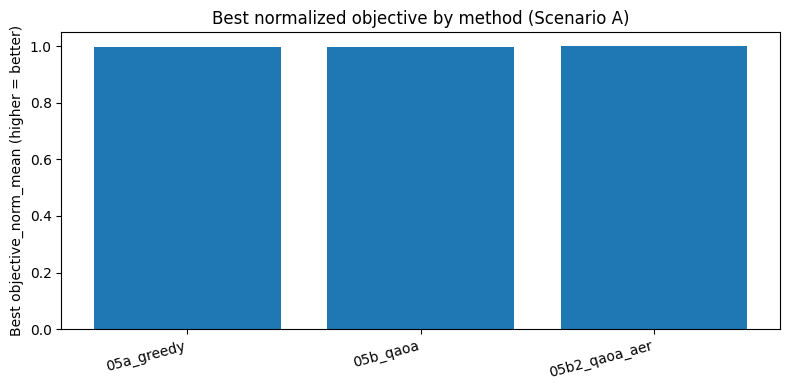

Saved: outputs/figures/05c2_best_objective_by_method.png


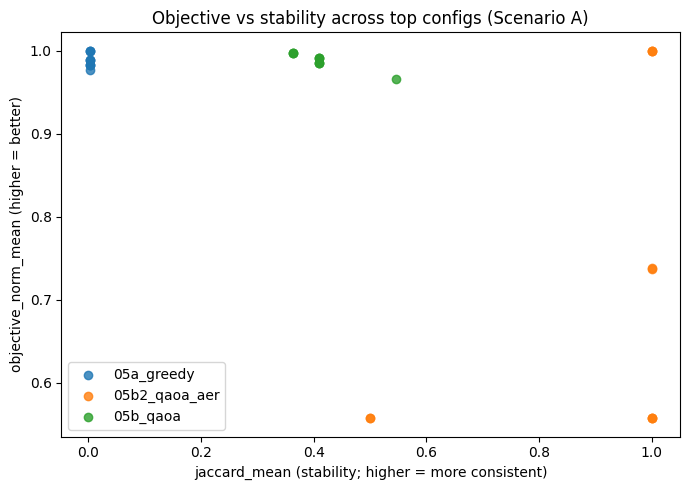

Saved: outputs/figures/05c2_objective_vs_stability_scatter.png


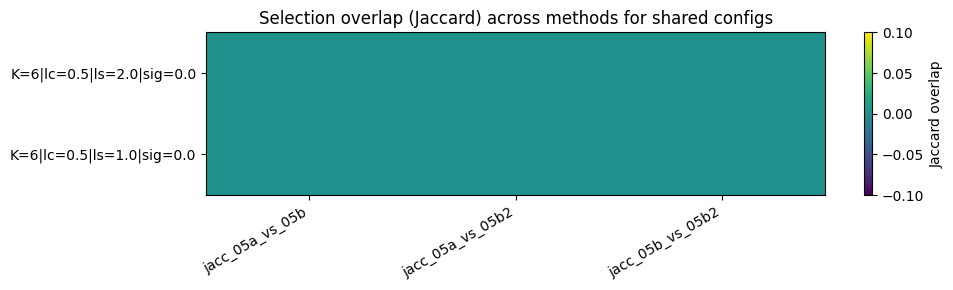

Saved: outputs/figures/05c2_jaccard_overlap_heatmap.png


In [10]:
# ============================================================
# Cell 6 — Visualizations 
# ============================================================

# --- Plot 1: Best objective_norm_mean by method ---
best_plot = best_all.copy()

# Ensure required cols exist
for c in ["method", "objective_norm_mean", "jaccard_mean"]:
    if c not in best_plot.columns:
        best_plot[c] = np.nan

best_plot["objective_norm_mean"] = pd.to_numeric(best_plot["objective_norm_mean"], errors="coerce")
best_plot["jaccard_mean"] = pd.to_numeric(best_plot["jaccard_mean"], errors="coerce")

plt.figure(figsize=(8, 4))
plt.bar(best_plot["method"].astype(str), best_plot["objective_norm_mean"].astype(float))
plt.ylabel("Best objective_norm_mean (higher = better)")
plt.title("Best normalized objective by method (Scenario A)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
fig1 = FIG_DIR / "05c2_best_objective_by_method.png"
plt.savefig(fig1, dpi=160)
plt.show()
print("Saved:", fig1)

# --- Plot 2: Objective vs stability scatter using all top-config rows ---
a = _dedupe_columns(top_05a_s.copy())
b = _dedupe_columns(top_05b_s.copy())
c = _dedupe_columns(top_05b2_s.copy())

# Align columns across the three frames before concat
all_cols = sorted(set(a.columns) | set(b.columns) | set(c.columns))
a = a.reindex(columns=all_cols)
b = b.reindex(columns=all_cols)
c = c.reindex(columns=all_cols)

all_top = pd.concat([a, b, c], ignore_index=True)

# Ensure plotting columns exist
for col in ["method", "objective_norm_mean", "jaccard_mean"]:
    if col not in all_top.columns:
        all_top[col] = np.nan

all_top["objective_norm_mean"] = pd.to_numeric(all_top["objective_norm_mean"], errors="coerce")
all_top["jaccard_mean"] = pd.to_numeric(all_top["jaccard_mean"], errors="coerce")

if all_top["objective_norm_mean"].isna().all():
    raise ValueError("objective_norm_mean is missing for all methods; cannot plot.")

plt.figure(figsize=(7, 5))
for method, g in all_top.groupby("method"):
    x = g["jaccard_mean"].astype(float)
    y = g["objective_norm_mean"].astype(float)
    plt.scatter(x, y, label=str(method), alpha=0.8)

plt.xlabel("jaccard_mean (stability; higher = more consistent)")
plt.ylabel("objective_norm_mean (higher = better)")
plt.title("Objective vs stability across top configs (Scenario A)")
plt.legend()
plt.tight_layout()
fig2 = FIG_DIR / "05c2_objective_vs_stability_scatter.png"
plt.savefig(fig2, dpi=160)
plt.show()
print("Saved:", fig2)

# --- Plot 3: Overlap heatmap across methods for shared configs (if data exists) ---
hm = overlap_df.copy()
if hm.empty:
    print("No overlap rows available; skipping overlap heatmap.")
else:
    hm = hm.set_index("config_key")[["jacc_05a_vs_05b", "jacc_05a_vs_05b2", "jacc_05b_vs_05b2"]]

    plt.figure(figsize=(10, max(3, 0.35 * len(hm))))
    img = plt.imshow(hm.values, aspect="auto", origin="lower")
    plt.colorbar(img, label="Jaccard overlap")
    plt.yticks(range(len(hm.index)), hm.index)
    plt.xticks(range(len(hm.columns)), hm.columns, rotation=30, ha="right")
    plt.title("Selection overlap (Jaccard) across methods for shared configs")
    plt.tight_layout()
    fig3 = FIG_DIR / "05c2_jaccard_overlap_heatmap.png"
    plt.savefig(fig3, dpi=160)
    plt.show()
    print("Saved:", fig3)

### What Cell 6 Just Did (Fixed)

- Fixed a Pandas `InvalidIndexError` by **deduplicating column names** and aligning columns before concatenating top-config tables.
- Produced three slide-friendly figures:
  1) Best normalized objective by method
  2) Objective vs stability scatter across each method’s top configs
  3) Method-to-method selection overlap heatmap (when shared configs exist)


In [11]:
# ============================================================
# Cell 7 — Wrap-up: artifact inventory and quick sanity checks
# ============================================================

print("Wrote CSVs:")
print("  -", RESULTS_DIR / "05c2_compare_best_by_method.csv")
print("  -", RESULTS_DIR / "05c2_compare_config_join_table.csv")
print("  -", RESULTS_DIR / "05c2_compare_selection_overlap_jaccard.csv")

print("\nWrote figures:")
print("  -", FIG_DIR / "05c2_best_objective_by_method.png")
print("  -", FIG_DIR / "05c2_objective_vs_stability_scatter.png")
print("  -", FIG_DIR / "05c2_jaccard_overlap_heatmap.png")

# Sanity checks
assert (RESULTS_DIR / "05c2_compare_best_by_method.csv").exists()
assert (RESULTS_DIR / "05c2_compare_config_join_table.csv").exists()
assert (RESULTS_DIR / "05c2_compare_selection_overlap_jaccard.csv").exists()

print("\nNotebook completed successfully.")

Wrote CSVs:
  - data/results/05c2_compare_best_by_method.csv
  - data/results/05c2_compare_config_join_table.csv
  - data/results/05c2_compare_selection_overlap_jaccard.csv

Wrote figures:
  - outputs/figures/05c2_best_objective_by_method.png
  - outputs/figures/05c2_objective_vs_stability_scatter.png
  - outputs/figures/05c2_jaccard_overlap_heatmap.png

Notebook completed successfully.


### What Cell 7 Just Did

- Printed the final list of artifacts produced by this comparison notebook.
- Performed basic existence checks so failures are caught immediately.
- Confirmed a successful end-to-end run.


## Summary

This notebook (`05c2_compare_greedy_vs_qaoa_vs_qaoa_aer_scenario_A.ipynb`) completed a three-way comparison of Scenario A robustness sweep results:

- **05a (Greedy)**
- **05b (QAOA, Aer-free)**
- **05b2 (QAOA + Aer)**

### What we produced
**Comparison datasets (CSV):**
- `data/results/05c2_compare_best_by_method.csv`  
  One “best config” row per method using a consistent ranking (primarily `objective_norm_mean`, tie-break `jaccard_mean`).
- `data/results/05c2_compare_config_join_table.csv`  
  A cross-method join over `(K, λ_cost, λ_safety, noise_sigma)` to show which configurations overlap across methods.
- `data/results/05c2_compare_selection_overlap_jaccard.csv`  
  Pairwise selection overlap (Jaccard) for configurations that exist in multiple methods’ exports.

**Slide-ready figures (PNG):**
- `outputs/figures/05c2_best_objective_by_method.png`
- `outputs/figures/05c2_objective_vs_stability_scatter.png`
- `outputs/figures/05c2_jaccard_overlap_heatmap.png` (if overlaps exist)

### Interpretation guidance (how to read the results)
- **`objective_norm_mean`**: higher means better relative objective performance *within the compared set*.
- **`jaccard_mean`**: higher means more stable selection relative to the method’s baseline (or reference) for that sweep.
- The **join table** tells you whether you are comparing identical configuration grids or partially disjoint sweeps (common cause of “no overlap” earlier).
